# Pokemon dataset - Pre-Processing and Exploratory Data Analysis

My primary aim with this project is just to poke around with different algorithms and functions, so to that end I'll be keeping the pre-processing somewhat minimal. 
- remove missing values
- encode categorical data
- split into training and test set
- explore variables and possibly some feature scaling

## Importing packages and data

In [57]:
# packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn as sk 
import seaborn as sns

In [58]:
# data
df = pd.read_csv("/home/joy/Documents/Education/Python Scripts/pokemon-data-science-project/data/pokemon_kaggle.csv")

In [59]:
df

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,719,Diancie,Rock,Fairy,600,50,100,150,100,150,50,6,True
796,719,DiancieMega Diancie,Rock,Fairy,700,50,160,110,160,110,110,6,True
797,720,HoopaHoopa Confined,Psychic,Ghost,600,80,110,60,150,130,70,6,True
798,720,HoopaHoopa Unbound,Psychic,Dark,680,80,160,60,170,130,80,6,True


In [60]:
print(df.columns)

Index(['#', 'Name', 'Type 1', 'Type 2', 'Total', 'HP', 'Attack', 'Defense',
       'Sp. Atk', 'Sp. Def', 'Speed', 'Generation', 'Legendary'],
      dtype='str')


In [61]:
# dataset discovery
# my aim here is to learn the main structure and schema of the dataset
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   #           800 non-null    int64
 1   Name        800 non-null    str  
 2   Type 1      800 non-null    str  
 3   Type 2      414 non-null    str  
 4   Total       800 non-null    int64
 5   HP          800 non-null    int64
 6   Attack      800 non-null    int64
 7   Defense     800 non-null    int64
 8   Sp. Atk     800 non-null    int64
 9   Sp. Def     800 non-null    int64
 10  Speed       800 non-null    int64
 11  Generation  800 non-null    int64
 12  Legendary   800 non-null    bool 
dtypes: bool(1), int64(9), str(3)
memory usage: 75.9 KB


In [62]:
df.describe()

,#,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation
count,800.000000,800.00000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.00000
mean,362.813750,435.10250,69.258750,79.001250,73.842500,72.820000,71.902500,68.277500,3.32375
std,208.343798,119.96304,25.534669,32.457366,31.183501,32.722294,27.828916,29.060474,1.66129
min,1.000000,180.00000,1.000000,5.000000,5.000000,10.000000,20.000000,5.000000,1.00000
25%,184.750000,330.00000,50.000000,55.000000,50.000000,49.750000,50.000000,45.000000,2.00000
50%,364.500000,450.00000,65.000000,75.000000,70.000000,65.000000,70.000000,65.000000,3.00000
75%,539.250000,515.00000,80.000000,100.000000,90.000000,95.000000,90.000000,90.000000,5.00000
max,721.000000,780.00000,255.000000,190.000000,230.000000,194.000000,230.000000,180.000000,6.00000


In [63]:
df.shape

(800, 13)

In [64]:
# check for missing values aside from Type 2, since some pokemon only have one type
df_missing_query = df.drop(["Type 2"], axis=1)
# Check for missing values
df_missing_query.isna().sum()

#             0
Name          0
Type 1        0
Total         0
HP            0
Attack        0
Defense       0
Sp. Atk       0
Sp. Def       0
Speed         0
Generation    0
Legendary     0
dtype: int64

In [65]:
# Check for duplicates
duplicates = df.duplicated().sum()

# Percentage of duplicated data
percentage = df.duplicated().sum() / df.shape[0] * 100

print(f'{duplicates} rows contain duplicates amounting to {percentage.round(2)}% of the total data.')

0 rows contain duplicates amounting to 0.0% of the total data.


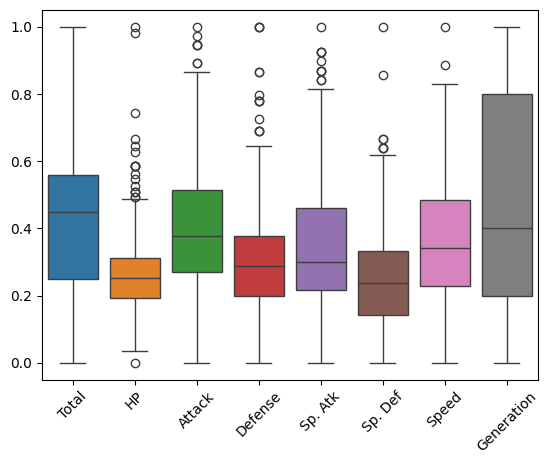

In [66]:
# Create a boxplot to visualize distribution of all numeric variables and detect any outliers

# plot 1 boxplot for all variables so must first normalize the scale
from sklearn.preprocessing import MinMaxScaler

# select numeric vs str columns
num_columns = df[df.select_dtypes(include=['int', 'int64', np.number]).columns]
str_columns = df[df.select_dtypes(include=['str']).columns]

# dropping the first column of num_columns since it's just the pokemon's number and has no statistical value
num_columns = num_columns.drop(["#"], axis=1)

#normalize values using min-max scaling
scaler = MinMaxScaler()
normalized_data = scaler.fit_transform(num_columns)

# Create df with normalized data
df_normalized = pd.DataFrame(normalized_data, columns=num_columns.columns)

sns.boxplot(data= df_normalized)
plt.xticks(rotation=45)

plt.show()


In [67]:
num_columns.corr()

,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation
Total,1.000000,0.618748,0.736211,0.612787,0.747250,0.717609,0.575943,0.048384
HP,0.618748,1.000000,0.422386,0.239622,0.362380,0.378718,0.175952,0.058683
Attack,0.736211,0.422386,1.000000,0.438687,0.396362,0.263990,0.381240,0.051451
Defense,0.612787,0.239622,0.438687,1.000000,0.223549,0.510747,0.015227,0.042419
Sp. Atk,0.747250,0.362380,0.396362,0.223549,1.000000,0.506121,0.473018,0.036437
Sp. Def,0.717609,0.378718,0.263990,0.510747,0.506121,1.000000,0.259133,0.028486
Speed,0.575943,0.175952,0.381240,0.015227,0.473018,0.259133,1.000000,-0.023121
Generation,0.048384,0.058683,0.051451,0.042419,0.036437,0.028486,-0.023121,1.000000


In [68]:
def find_iqr_outliers(df):
    for column in df:
        print('Column Name : ', column)
        
        # calculations
        
        # Compute the 25th percentile value
        percentile25 = df[column].quantile(0.25)

        # Compute the 75th percentile value
        percentile75 = df[column].quantile(0.75)

        # Compute the interquartile range
        iqr = percentile75 - percentile25

        # Define the upper limit and lower limit for non-outlier values 
        upper_limit = percentile75 + 1.5 * iqr
        lower_limit = percentile25 - 1.5 * iqr
        print("Lower limit:", lower_limit)
        print("Upper limit:", upper_limit)

        # Identify subset of data containing outliers 
        outliers = df[(df[column] > upper_limit) | (df[column] < lower_limit)]

        # Count how many rows in the data contain outliers 
        print("Number of rows in the data containing outliers in " , column, " :", len(outliers))
        
        print('=' * 60)

In [69]:
# recall, we made a sub-df with number columns earlier
find_iqr_outliers(num_columns)

Column Name :  Total
Lower limit: 52.5
Upper limit: 792.5
Number of rows in the data containing outliers in  Total  : 0
Column Name :  HP


Lower limit: 5.0
Upper limit: 125.0
Number of rows in the data containing outliers in  HP  : 19
Column Name :  Attack
Lower limit: -12.5
Upper limit: 167.5
Number of rows in the data containing outliers in  Attack  : 7
Column Name :  Defense
Lower limit: -10.0
Upper limit: 150.0
Number of rows in the data containing outliers in  Defense  : 13
Column Name :  Sp. Atk
Lower limit: -18.125
Upper limit: 162.875
Number of rows in the data containing outliers in  Sp. Atk  : 10
Column Name :  Sp. Def
Lower limit: -10.0
Upper limit: 150.0
Number of rows in the data containing outliers in  Sp. Def  : 7
Column Name :  Speed
Lower limit: -22.5
Upper limit: 157.5
Number of rows in the data containing outliers in  Speed  : 2
Column Name :  Generation
Lower limit: -2.5
Upper limit: 9.5
Number of rows in the data containing outliers in  Generation  : 0


## EDA Visualisation

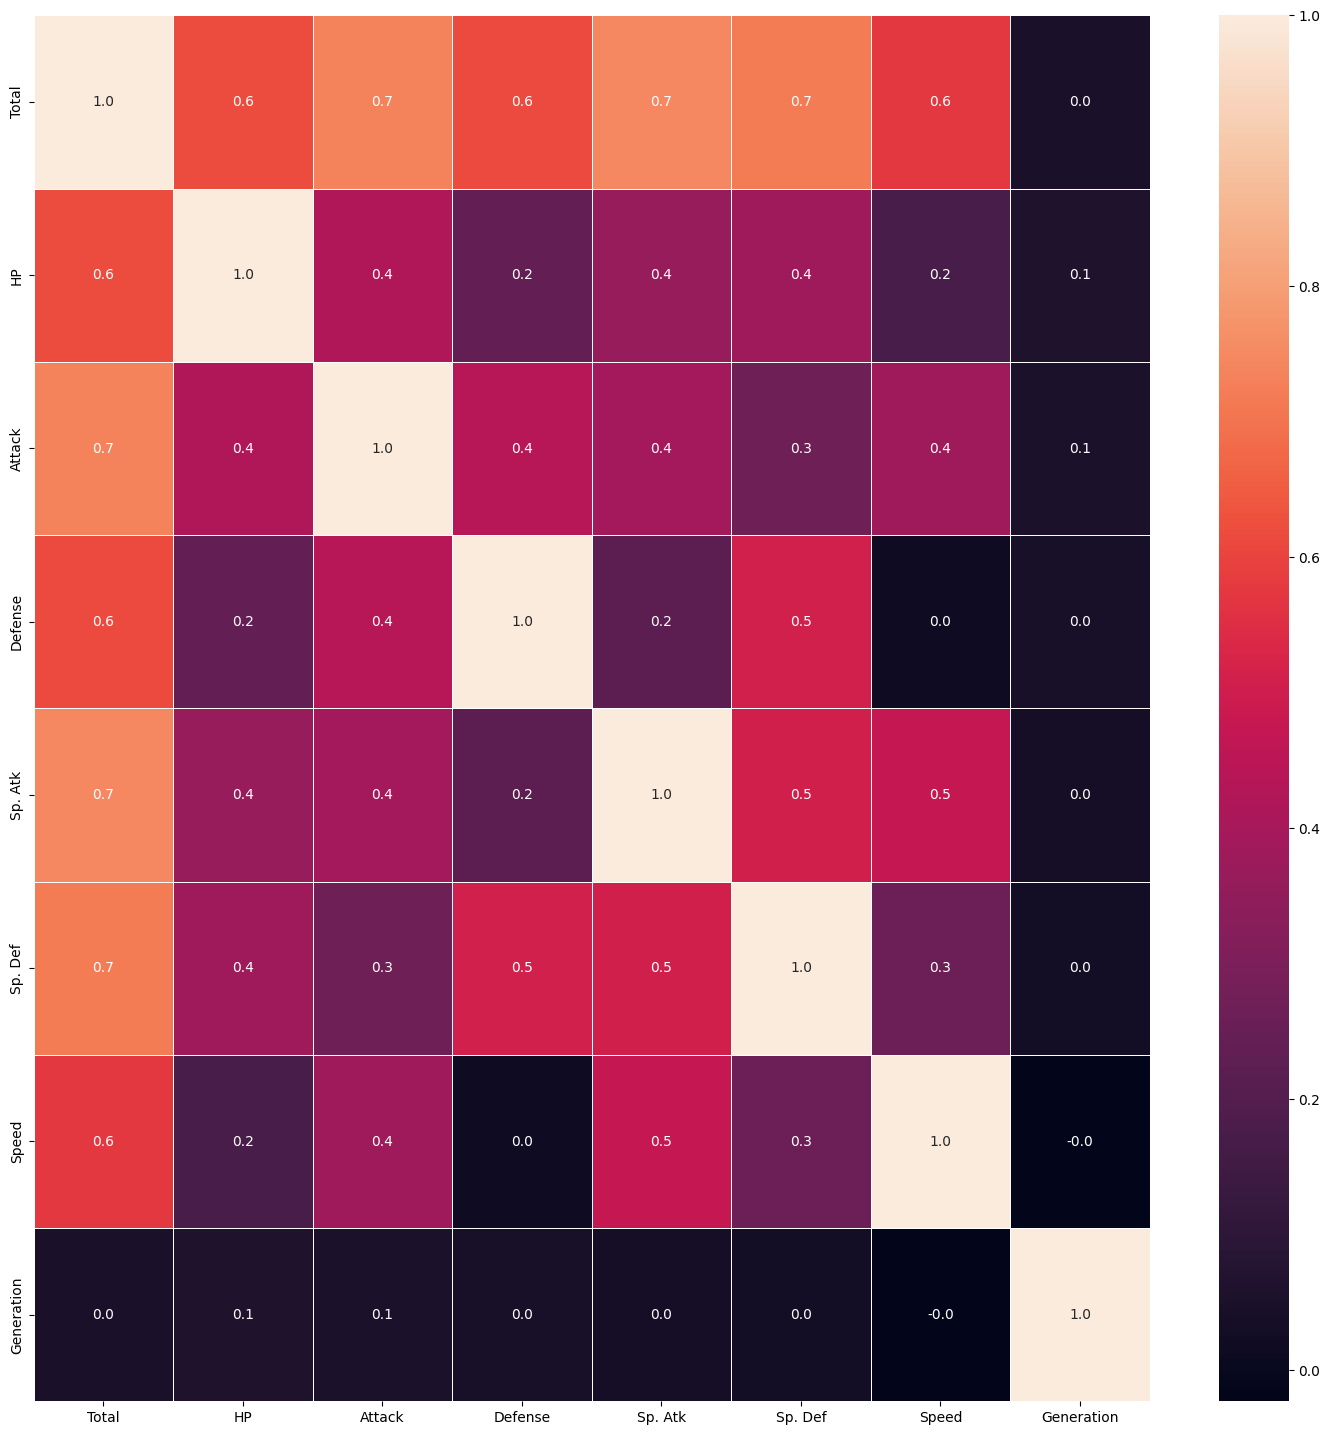

In [70]:
f,ax = plt.subplots(figsize=(18, 18))
sns.heatmap(num_columns.corr(), annot=True, linewidths=.5, fmt= '.1f',ax=ax) #remove annot=True, and cee the difference
plt.show()

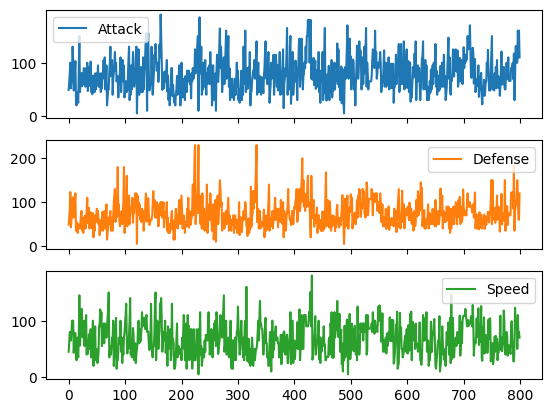

In [71]:
basic_stats = df.loc[:,["Attack","Defense","Speed"]]
basic_stats.plot(subplots = True)
plt.show()

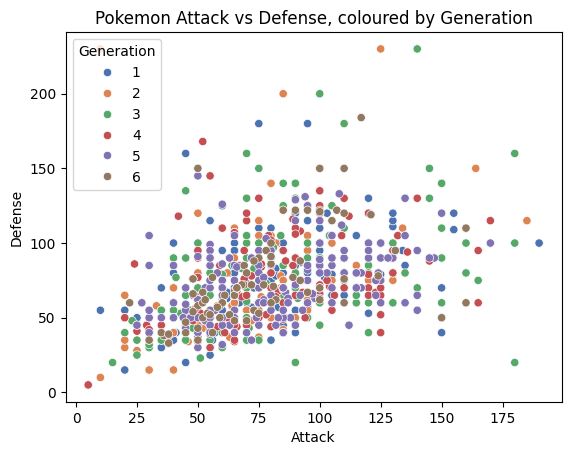

In [73]:
sns.scatterplot(data=df, x="Attack", y="Defense", hue="Generation", palette="deep")
plt.title("Pokemon Attack vs Defense, coloured by Generation")
plt.show()

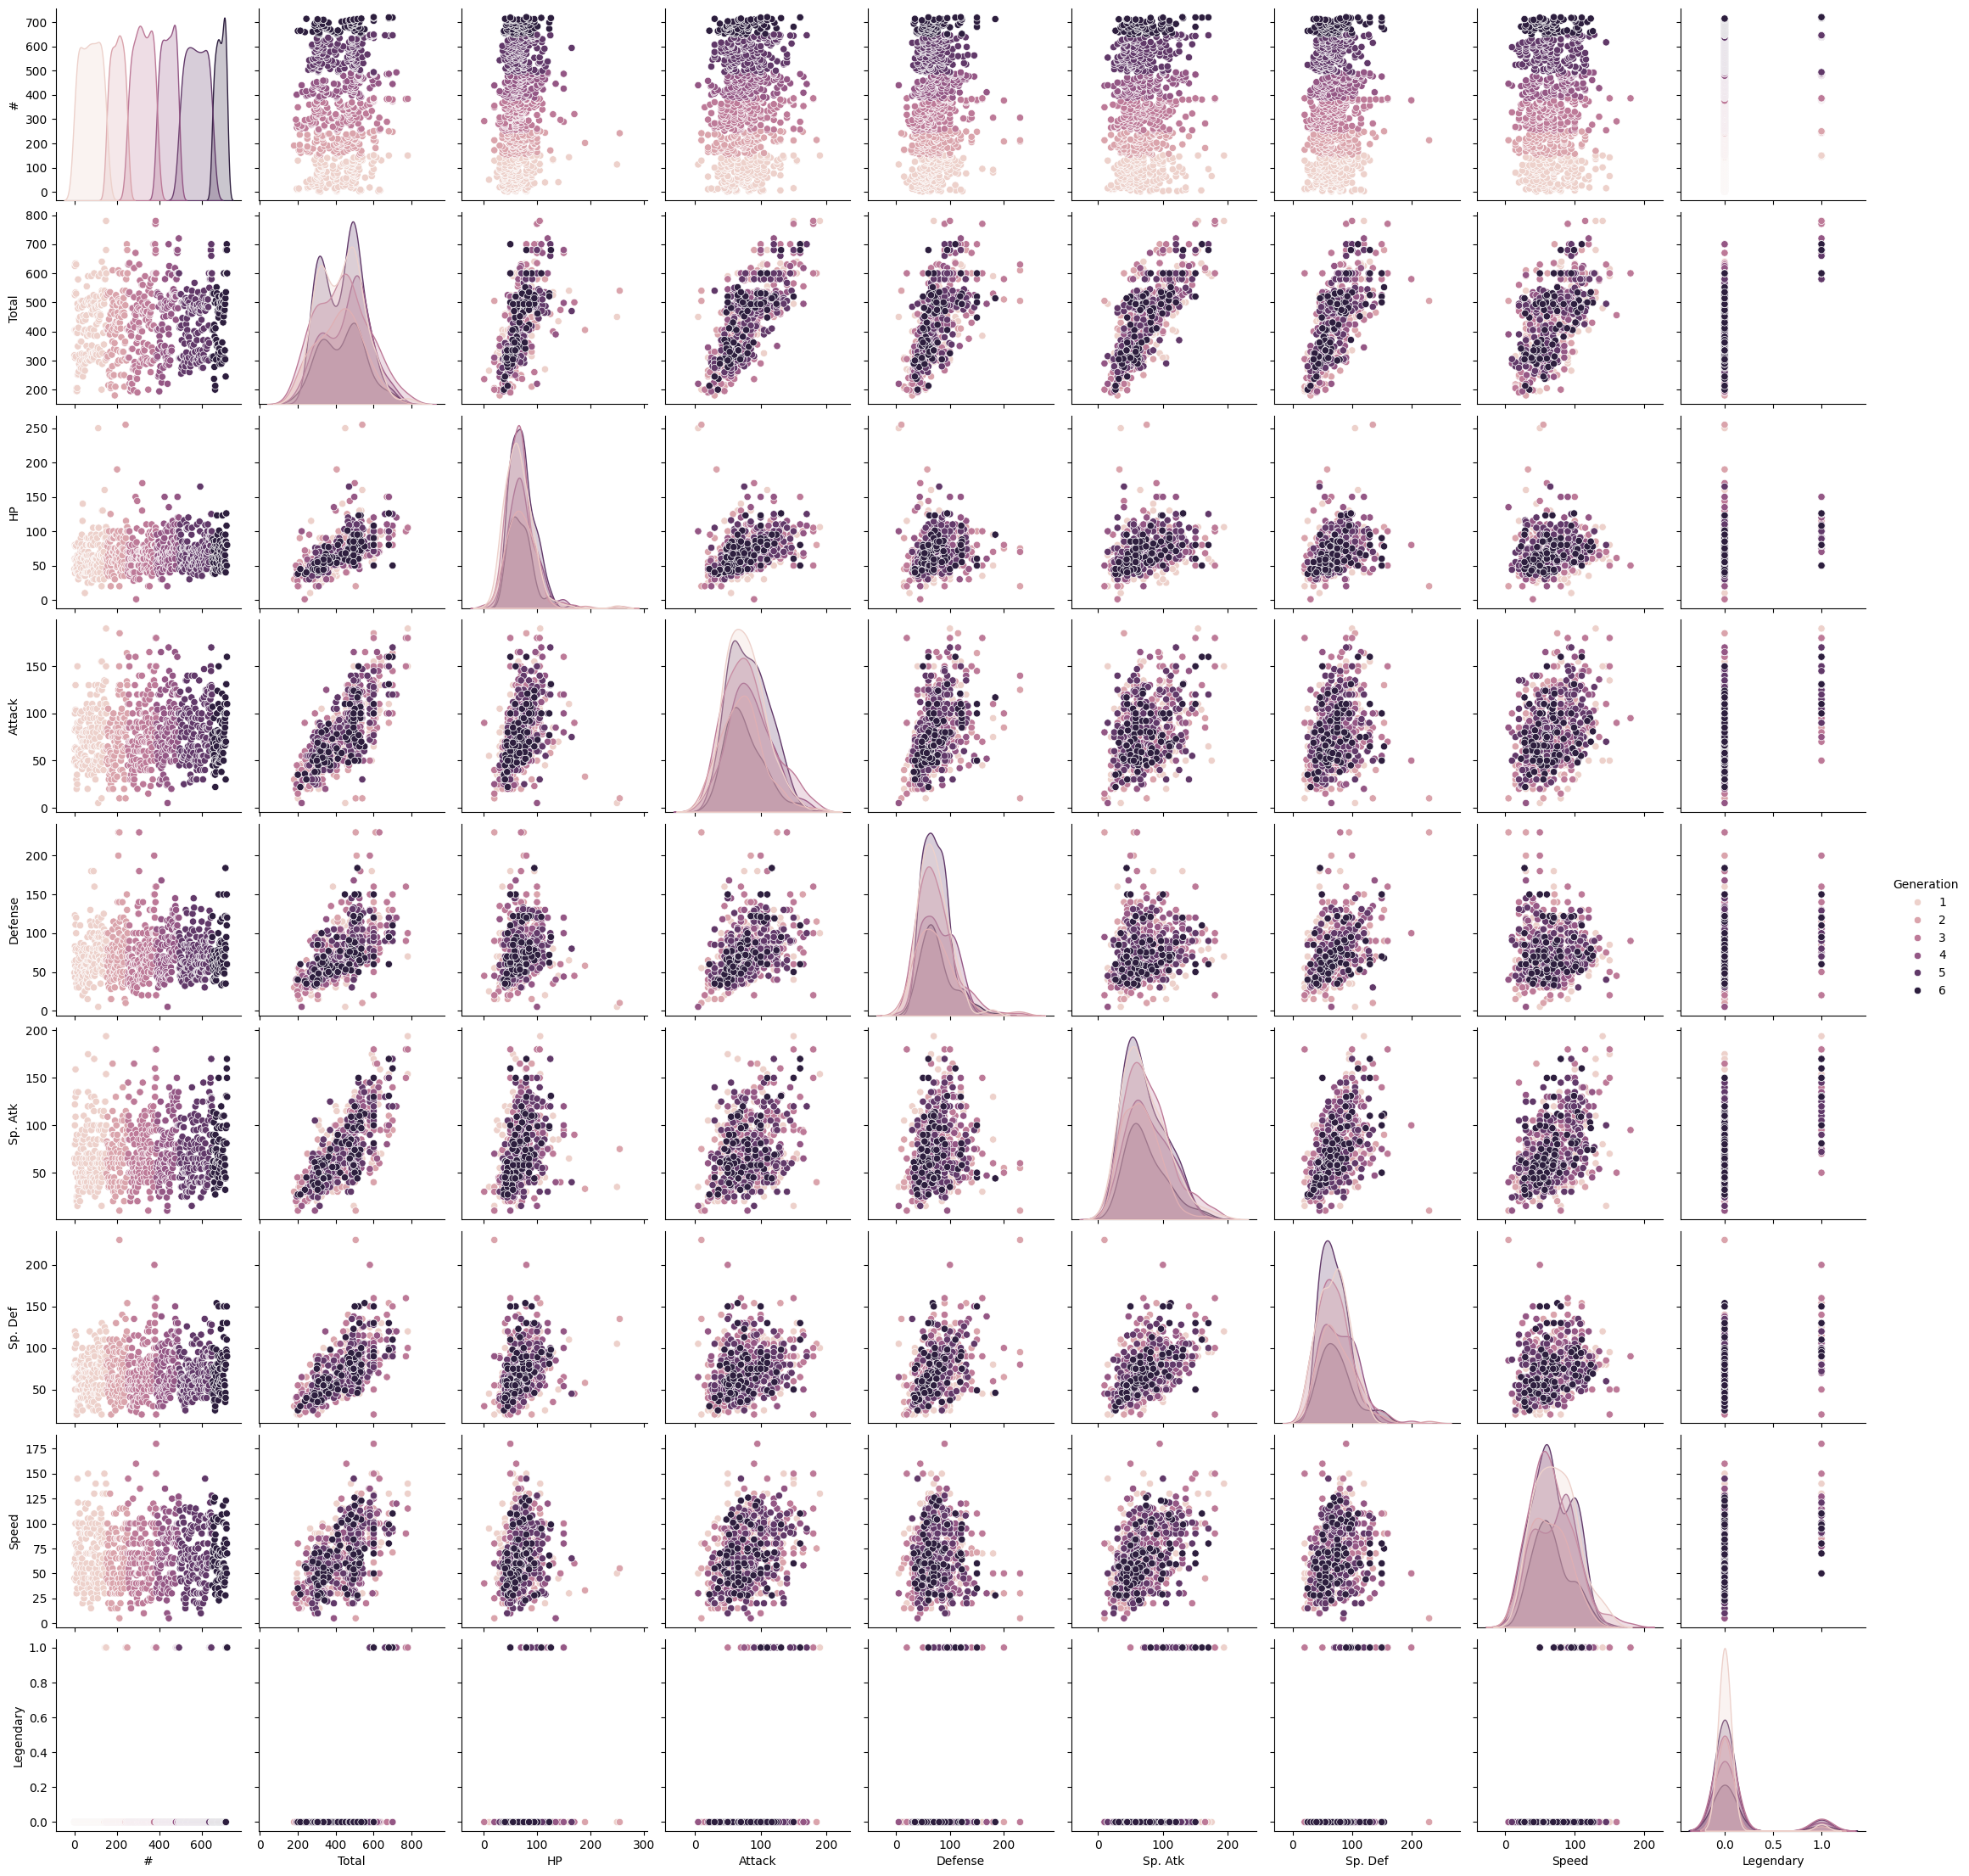

In [75]:
sns.pairplot(df, hue="Generation")